✅  Loaded student_processed.csv  →  shape: (395, 34)

  5.1  FEATURE ENGINEERING
  New features created:
    • avg_parent_edu     — Average of mother & father education levels
    • avg_grade          — Average of G1 & G2 (mid-term performance proxy)
    • alcohol_total      — Weekday + weekend alcohol consumption
    • social_index       — goout + freetime − studytime (distraction proxy)

  5.2  DEFINE FEATURES (X) AND TARGET (y)
  Features (X) : 36 columns
  Target   (y) : 395 rows  |  Pass=117  Fail=278

  5.3  MUTUAL INFORMATION FEATURE SELECTION

  All features ranked by Mutual Information:
       Feature  MI Score
     avg_grade    0.2425
            G2    0.1705
          Fedu    0.0598
          paid    0.0558
      absences    0.0466
            G1    0.0465
          Fjob    0.0393
       famsize    0.0294
          Dalc    0.0273
        reason    0.0249
     schoolsup    0.0200
          Walc    0.0139
avg_parent_edu    0.0129
      internet    0.0121
        higher    0.00

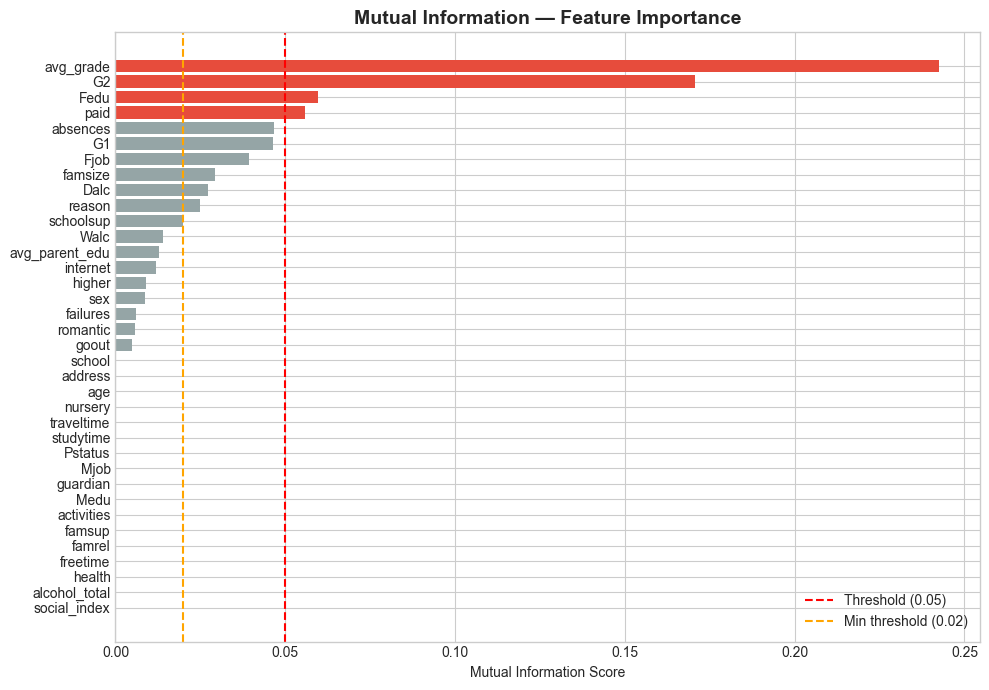


  Plot saved → ../docs/feature_importance_mi.png

  Features selected (MI > 0.02): 10
    • avg_grade
    • G2
    • Fedu
    • paid
    • absences
    • G1
    • Fjob
    • famsize
    • Dalc
    • reason

✅  Stage 5 complete.
    Saved : ../data/student_features.csv
    Saved : ../data/selected_features.txt
    Next  : python stage6_model_building.py  (Aparna)


In [1]:
# =============================================================================
# STAGE 5 — Feature Engineering & Selection
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage5_feature_engineering.py   (after stage4)
# Input  : ../data/student_processed.csv
# Output : ../data/student_features.csv   (used by Stage 6)
#          ../data/selected_features.txt
# =============================================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

DOCS_DIR = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)


# ── Load from Stage 3 output ──────────────────────────────────────────────────
def load_data():
    path = "../data/student_processed.csv"
    if not os.path.exists(path):
        raise FileNotFoundError(
            "student_processed.csv not found.\n"
            "Please run stage3_preprocessing.py first."
        )
    df = pd.read_csv(path)
    print(f"✅  Loaded student_processed.csv  →  shape: {df.shape}\n")
    return df


# ── 5.1  Create New Engineered Features ──────────────────────────────────────
def engineer_features(df):
    print("=" * 55)
    print("  5.1  FEATURE ENGINEERING")
    print("=" * 55)

    df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
    df["avg_grade"]      = (df["G1"]   + df["G2"])   / 2
    df["alcohol_total"]  = df["Dalc"]  + df["Walc"]
    df["social_index"]   = df["goout"] + df["freetime"] - df["studytime"]

    new_features = {
        "avg_parent_edu": "Average of mother & father education levels",
        "avg_grade"     : "Average of G1 & G2 (mid-term performance proxy)",
        "alcohol_total" : "Weekday + weekend alcohol consumption",
        "social_index"  : "goout + freetime − studytime (distraction proxy)",
    }
    print("  New features created:")
    for feat, desc in new_features.items():
        print(f"    • {feat:<18} — {desc}")
    print()
    return df


# ── 5.2  Define X and y ───────────────────────────────────────────────────────
def define_X_y(df):
    print("=" * 55)
    print("  5.2  DEFINE FEATURES (X) AND TARGET (y)")
    print("=" * 55)
    # Drop G3 (raw final grade) to prevent data leakage
    # G1 and G2 are kept individually AND as avg_grade
    X = df.drop(["G3", "pass"], axis=1)
    y = df["pass"]
    print(f"  Features (X) : {X.shape[1]} columns")
    print(f"  Target   (y) : {y.shape[0]} rows  |  "
          f"Pass={y.sum()}  Fail={(y==0).sum()}")
    return X, y


# ── 5.3  Mutual Information Feature Selection ─────────────────────────────────
def select_features(X, y):
    print("\n" + "=" * 55)
    print("  5.3  MUTUAL INFORMATION FEATURE SELECTION")
    print("=" * 55)

    # Scale to [0,1] for MI computation
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
    mi_df = (
        pd.DataFrame({"Feature": X.columns, "MI Score": mi_scores})
        .sort_values("MI Score", ascending=False)
        .reset_index(drop=True)
    )

    print("\n  All features ranked by Mutual Information:")
    print(mi_df.round(4).to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#e74c3c" if s > 0.05 else "#95a5a6" for s in mi_df["MI Score"]]
    ax.barh(mi_df["Feature"][::-1], mi_df["MI Score"][::-1],
            color=colors[::-1])
    ax.set_title("Mutual Information — Feature Importance",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Mutual Information Score")
    ax.axvline(0.05, color="red", linestyle="--",
               linewidth=1.5, label="Threshold (0.05)")
    ax.axvline(0.02, color="orange", linestyle="--",
               linewidth=1.5, label="Min threshold (0.02)")
    ax.legend()
    plt.tight_layout()
    out = f"{DOCS_DIR}/feature_importance_mi.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Plot saved → {out}")

    # Select features above threshold
    THRESHOLD = 0.02
    selected = mi_df[mi_df["MI Score"] > THRESHOLD]["Feature"].tolist()
    print(f"\n  Features selected (MI > {THRESHOLD}): {len(selected)}")
    for f in selected:
        print(f"    • {f}")

    return selected, mi_df


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data()
    df = engineer_features(df)
    X, y = define_X_y(df)
    selected_features, mi_df = select_features(X, y)

    # Save full featured dataframe and selected feature list
    df_out = X[selected_features].copy()
    df_out["pass"] = y.values
    df_out.to_csv("../data/student_features.csv", index=False)

    with open("../data/selected_features.txt", "w") as f:
        f.write("\n".join(selected_features))

    print(f"\n✅  Stage 5 complete.")
    print(f"    Saved : ../data/student_features.csv")
    print(f"    Saved : ../data/selected_features.txt")
    print("    Next  : python stage6_model_building.py  (Aparna)")
